# Bayesian Regression Revisited

This notebook aims at showing regression in a Bayesian context from a slightly different perspective to make the conceptual distinction with Frequentist regression (see also [Bayes_philosophy.ipynb](Bayes_philosophy.ipynb)) a bit clearer. 

## Another view on regression 

Let's look back at the example of the straight line.    
Our model is a straight line $y = \theta_1 \, x + \theta_0$. In a situation where we have no data, and a flat prior on $(\theta_0, \theta_1)$, all values of $(\theta_0, \theta_1)$ are possible. If for some reasons we know that we expect $\theta_0 \in [-1, 1]$ and $\theta_1 \in [0, 2]$, then we have restricted our plane simply because of our prior. 

Then we do our experiment and get the first data point $(x_1, y_1) = (-1, -1.004)$ with an uncertainty $\sigma_y = 0.01)$. There is an infinity of lines that go through that point BUT NOT all pairs of $(\theta_0,\theta_1)$ are possible, only those along the line of equation $\theta_1 = \theta_0 + 1.004 $

More formally, we can calculate a likelihood and a credible interval around that region of the parameter space.

Remember that for a point $y_i$ we have 

$$
p(y_i\,\mid\,\boldsymbol{\theta} ) = \frac{1}{\sigma \sqrt{2\,\pi}} \, \exp\left[-0.5 \left (\frac{y_i - (\theta_1 \, x_i + \theta_0) }{\sigma} \right)^2\right] 
$$

So, we can write our log likelihood for our point $(x_1, y_1)$: 

$$
\ln(P(D\mid\boldsymbol{\theta})) \, = -\frac{1}{2}\,\left (\ln(2\pi\sigma^2) + \frac{ (y_1 - (\theta_0+\theta_1\,x_1))^2}{\sigma^2} \right) 
$$


In [1]:
import numpy as np
from matplotlib import pyplot as plt
# Let's evaluate the likelihood via a gridding in the range defined by our prior
theta1_range = np.linspace(0, 2, 100)
theta0_range = np.linspace(-1, 1, 100)
x1, y1 = -1, -1.004
dy = 0.01

# Let's evaluate the likelihood for all pairs of parameters (theta0, thetha1)
# We can use a for loop and meshgrid but we can also proceed as follows
THETA1 = theta1_range[:, None]  # shape (100, 1)
THETA2 = theta0_range[None, :]  # shape (1, 100)

logL_x1 = -(((THETA1 * x1 + 
          THETA2) - y1) / dy) ** 2

Text(0.5, 1.0, 'DATA')

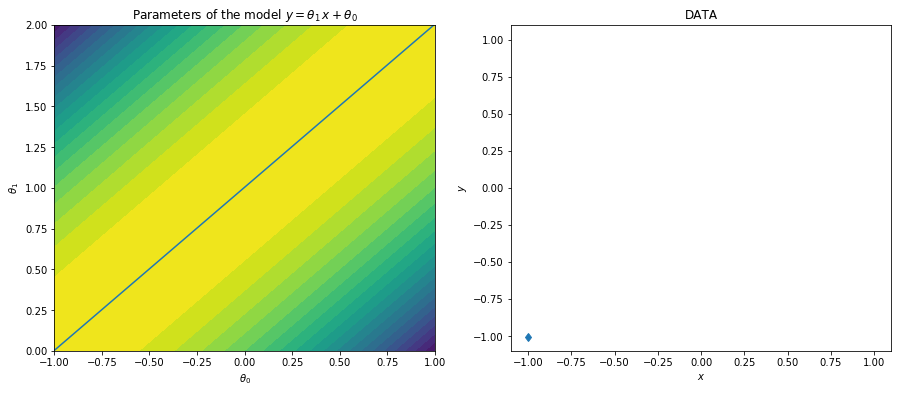

In [2]:
f, ax = plt.subplots(figsize=(15,6), ncols=2)
ax[0].contourf(theta0_range, theta1_range, logL_x1, levels=20)
maxL_x1 = theta0_range + 1.004
ax[0].plot(theta0_range, maxL_x1)
ax[0].set_xlabel(r'$\theta_0$')
ax[0].set_ylabel(r'$\theta_1$')
ax[0].set_ylim(0,2)
ax[0].set_xlim(-1,1)
ax[0].set_title(r'Parameters of the model $y = \theta_1 \, x + \theta_0 $')
#-----
# Data point 
ax[1].errorbar(x1, y1, yerr=dy, marker='d')
ax[1].set_xlabel(r'$x$')
ax[1].set_ylabel(r'$y$')
ax[1].set_ylim(-1.1,1.1)
ax[1].set_xlim(-1.1,1.1)
ax[1].set_title('DATA')

We can convert the plot in the left panel to a probability contour (but this is not critical for our illustration). Note here that our "frequentist regression would have been a bit in trouble in the sense that we would have -1 degree of freedom. So we wouldn't be able to provide any "best fit" for our parameters. But information is provided by this single data point (in the framework of our model !).  

We could have obtained another constraint on $(\theta_0,\theta_1)$ if we had measured another data point $(x_2, y_2) = (0.5, 0.4998)$. In that case only $(\theta_0,\theta_1)$ following the line of equation $y_2 = \theta_1 x_2 + \theta_0$, so replacing $(x_2, y_2)$ the parameters follow the line of equation $\theta_1 = (0.5 - \theta_0) / 0.4998$ 

In [3]:
x2, y2 = 0.5, 0.4998
dy = 0.01

logL_x2 = -(((THETA1 * x2 + 
          THETA2) - y2) / dy) ** 2

Text(0.5, 1.0, 'DATA')

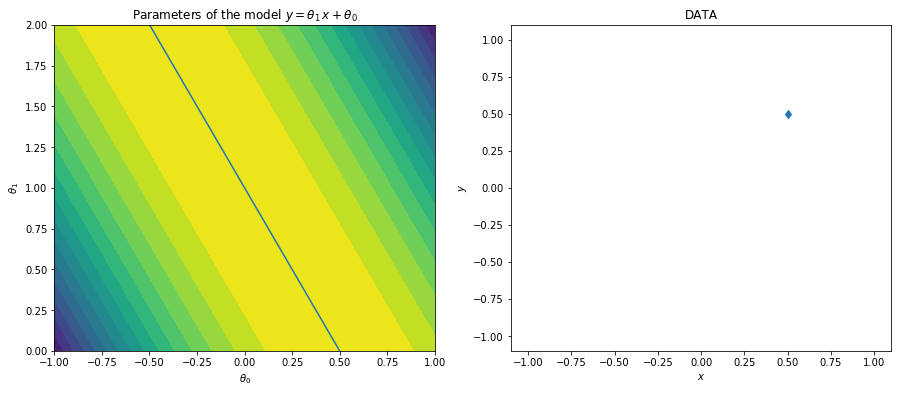

In [4]:
f, ax = plt.subplots(figsize=(15,6), ncols=2)
ax[0].contourf(theta0_range, theta1_range, logL_x2, levels=20)
maxL_x2 = (0.5 - theta0_range) / 0.4998
ax[0].plot(theta0_range, maxL_x2)
ax[0].set_xlabel(r'$\theta_0$')
ax[0].set_ylabel(r'$\theta_1$')
ax[0].set_ylim(0,2)
ax[0].set_xlim(-1,1)
ax[0].set_title(r'Parameters of the model $y = \theta_1 \, x + \theta_0 $')
#-----
# Data point 
ax[1].errorbar(x2, y2, yerr=dy, marker='d')
ax[1].set_xlabel(r'$x$')
ax[1].set_ylabel(r'$y$')
ax[1].set_ylim(-1.1,1.1)
ax[1].set_xlim(-1.1,1.1)
ax[1].set_title('DATA')

If we had now measured the 2 data points, we would have $\ln(P(D\mid\boldsymbol{\theta})) = \ln(P(x_1,y_1) \mid\boldsymbol{\theta})) + \ln(P(x_2,y_2) \mid\boldsymbol{\theta}))$. 

Text(0.5, 1.0, 'DATA')

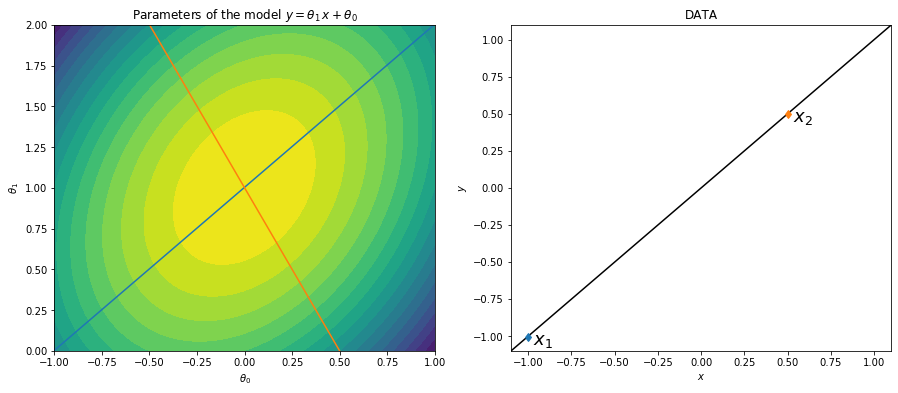

In [5]:
f, ax = plt.subplots(figsize=(15,6), ncols=2)
ax[0].contourf(theta0_range, theta1_range, logL_x1+logL_x2, levels=20)
ax[0].plot(theta0_range, maxL_x1, label = 'Constraint from (x1, y1)')
ax[0].plot(theta0_range, maxL_x2, label = 'Constraint from (x2, y2)')
ax[0].set_xlabel(r'$\theta_0$')
ax[0].set_ylabel(r'$\theta_1$')
ax[0].set_ylim(0,2)
ax[0].set_xlim(-1,1)
ax[0].set_title(r'Parameters of the model $y = \theta_1 \, x + \theta_0 $')
#-----
# Data point 
ax[1].errorbar(x1, y1, yerr=dy, marker='d')
ax[1].text(x1+0.03, y1-0.05, '$x_1$', size=18)
ax[1].text(x2+0.03, y2-0.05, '$x_2$', size=18)
ax[1].plot(np.linspace(-1.1,1.1,10), np.linspace(-1.1,1.1,10), color='black')
ax[1].errorbar(x2, y2, yerr=dy, marker='d')
ax[1].set_xlabel(r'$x$')
ax[1].set_ylabel(r'$y$')
ax[1].set_ylim(-1.1,1.1)
ax[1].set_xlim(-1.1,1.1)
ax[1].set_title('DATA')

This can be generalised to $n$ data points. It nicely illustrates the "Bayesian" idea that each data point inform us about the parameters of our model, or stated differently, how the constraints on the parameters respond to observations. 

Note also in that framework that it is also easy to account for a lower/upper limit on a data point. Instead of limiting $(\theta_0, \theta_1)$ to a line, a *lower/upper limit* would delimit a fraction of the plane with allowed/forbidden values of $(\theta_0, \theta_1)$.  

## Credible Intervals 

One aspect that might be bugging you is the fact that we state that in the frequentist framework we are calculating only a best value of the parameters while in the Bayesian approach we get the full pdf. However, we also provide uncertainties and sometimes even distributions associated to those parameters. While those distribution *can* be the effectively the same (remember that the $\chi^2$ in Frequentist optimisation maximizes the likelihood, so for ranges of priors you may end up with a posterior that has the same shape as the likelihood), they do **not** really mean the same thing. 

Remember that the **confidence interval** obtained in the frequentist way is a statement about the probability that the true value is encompassed within that interval. It is based on $p(x | \boldsymbol{\theta})$, where ${x_i}$ are the data points and $\boldsymbol{\theta}$ the parameters of the model. In the Bayesian framework, we infer the posterior distribution on parameters $\boldsymbol{\theta}$ (i.e. $p(\boldsymbol{\theta} | x)$). The latter allows us to calculate a **credible interval** based on the probability encompassed within specific percentiles of the posterior distribution. A credible interval is really a probability statement about the value of a parameter (there is a given probability for this parameter to fall within a given range) given the *data in hands and prior information*. This latter point is important: the posterior is derived  **only based on the data in hands** *and* some prior information $p(\theta)$ on the parameters/problem. Compared to the confidence interval, we have not made any assumption regarding repetition of a new data set to make this probabilistic statement. In addition, we account for the prior, something that the confidence interval does not do. 

## Another illustration 

Along the same line, we can also see the evolution of the likelihood in the framework of the last exercise of [Bayes_modeling.ipynb](Bayes_modeling.ipynb). 

We generate a fake data set as in [Bayes_modeling.ipynb](Bayes_modeling.ipynb). This data set corresponds to correlated points in x and y. The underlying model is a straight line of equation $y = b + a * x$ with a being the slope and b being the intercept. The data are generated assuming a gaussian noise in y, with a standard deviation $\sigma_y$.  

<ErrorbarContainer object of 3 artists>

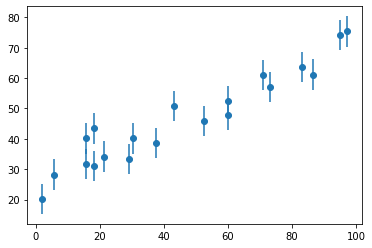

In [6]:
# Function that generates points following a linear trend. 
def make_data(intercept, slope, N=20,sigy=5, rseed=42):
    '''
    Parameters:
    -----------
    intercept, slope: parameters of the linear model
    sigy: width of normally distributed data points around the "true line"
    rseed: Seed of the random number generator (fixed for the sake of discussion)
    Output:
    -------
    x, y, sig_y 
    '''
    rand = np.random.RandomState(rseed)
    x = 100 * rand.rand(N)
    y = intercept + slope * x
    y += sigy * rand.randn(N)
    return x, y, sigy * np.ones_like(x)

theta_true = [25, 0.5]
x, y, sigy = make_data(theta_true[0], theta_true[1], N=20)  # could also be make_data(*theta_true)
plt.errorbar(x, y, sigy, fmt='o')

Let's define the function that calculate the prior. 

In [7]:
def ln_flat_prior(theta):
    '''
    theta = shape(2) array containing the [intercept, slope] = [theta_0, theta_1]
    '''
    if np.abs(theta[1]) < 1000:
        return 0 # log(1)
    else:
        return -np.inf  # log(0)
    
def ln_symmetric_prior(theta):
    '''
    theta = shape(2) array containing the [intercept, slope] = [theta_0, theta_1]
    '''
    if np.abs(theta[1]) < 1000:
        return -1.5 * np.log(1 + theta[1] ** 2)
    else:
        return -np.inf  # log(0)

And the one calculation the (log) likelihood. 

In [8]:
def ln_likelihood(theta, x, y, sigy):
    y_model = theta[0] + theta[1] * x
    return -0.5 * np.sum(np.log(2 * np.pi * sigy ** 2) + (y - y_model) ** 2 / sigy ** 2)

Now a function to evaluate the posterior on a grid of values for the slope and the intercept. 

In [9]:
# Use the cells below to evaluate the log likelihood for each of the two priors above
# Function that returns an array ln(posterior) for a flat/symmetric prior on a grid of values for the slope and intercept
def ln_P(x, y, sigy, slope_limits=[0.3, 0.7], intercept_limits=[15,35], prior_type='flat'):
    '''
    Function to calculate ln(posterior) for a flat prior (prior_type = 'flat') 
    or for a symmetric priot (prior_type='symmetric') 
    **on a grid of values** for the slope and intercept

    Parameters:
    -----------
    x: np.array(npts) - data: x
    y: np.array(npts) - data: y
    sigy: np.array(npts) - data: sigma_y
    slope_limits: list - range of slopes ; default=[0.3, 0.7]
    intercept_limits: list - range of intercepts ; default= [15,35]
    
    Returns: ln(posterior)
    '''
    neval = 100  # number of times I evaluate the posterior for a given parameter
    slope_range = np.linspace(slope_limits[0], slope_limits[1], neval)   # Vector containing 100 sampled values of theta_0 = slope
    intercept_range = np.linspace(intercept_limits[0], intercept_limits[1], neval)  # Vector containing the 100 sampled values of theta_1 = intercept 
    lnP_arr = np.zeros(shape=(neval, neval))  # 2D array where the posteriors will be saved. 

    for i, intercept in enumerate(intercept_range):
        for j, slope in enumerate(slope_range):
            theta = np.array([intercept, slope])

            if prior_type == 'flat':
                lnproba = ln_flat_prior(theta) + ln_likelihood(theta, x, y, sigy)

            if prior_type == 'symmetric':
                lnproba = ln_symmetric_prior(theta) + ln_likelihood(theta, x, y, sigy)
                
            lnP_arr[i, j] = lnproba
    return lnP_arr

In [10]:
# Create the grid of SLOPES/INTERCEPTS values for which you have evaluated ln(posterior) 
# TIP: Use np.meshgrid
slope_limits=[0.1, 1.0]   # [0.3, 0.7]
intercept_limits=[5,50]   # 15, 35
slope_range = np.linspace(slope_limits[0], slope_limits[1], 200)
intercept_range = np.linspace(intercept_limits[0], intercept_limits[1], 200)
SLOPE, INTERCEPT = np.meshgrid(slope_range, intercept_range)

In [11]:
# Function to make calculation and plot in once 
def plot_results(x, y, dy, ax, 
                 slope_limits=(0.1, 1.0),
                 intercept_limits=(5, 50), outcontour = False):
    '''
    Quick function to show the gridded posterior
    Limited docstring
    ax: axis object 
    outcontour: if True, returns ONLY the data needed to plot the contours of the posterior
                slope_range, intercept_range, P2, contour_levels(P2)
    '''
    
    # 1. Evaluate the log probability on the grid (once for each prior)
    slope_range = np.linspace(*slope_limits)    
    intercept_range = np.linspace(*intercept_limits)

    log_P2 = [[ln_likelihood([b, m], x, y, dy) + ln_symmetric_prior([b, m])
               for m in slope_range] for b in intercept_range]

    # For convenience, we normalize the probability density such that the maximum is 1
    P2 = np.exp(log_P2 - np.max(log_P2))

    if outcontour:
        return slope_range, intercept_range, P2, contour_levels(P2)
    
    # 2. Create two subplots and plot contours showing the results
#    fig, ax = plt.subplots(1, 1, figsize=(8, 6),
#                           sharex=True, sharey=True)

    ax.contourf(slope_range, intercept_range, P2, 100, cmap='Blues')
    ax.contour(slope_range, intercept_range, P2, contour_levels(P2), colors='black')
    
    # 3. Add grids and set axis labels
    ax.grid('on', linestyle=':', color='gray', alpha=0.5)
    ax.set_axisbelow(False)
    ax.set_xlabel('slope')
    ax.set_ylabel('intercept')
    ax.plot(theta_true[1], theta_true[0], 'd', color='orange')  # input value when generating data
    
    return ax 

In [12]:
# Function to compute 1, 2, 3-sigma contour levels for a gridded 2D posterior 
# Gaussian assumption for the levels 
def contour_levels(grid):
    """
    Compute 1, 2, 3-sigma contour levels for a gridded 2D posterior
    In 2D - assuming a Gaussian bivariate distribution, 
    the [68, 95, 99.7] levels correspond to [39.3, 86.5, 98.9] contours
    (see V.2.2.4 in Bayes_MCMC.ipynb)
    
    Parameter: 
    ----------
    grid: np.array((n,n)) - 2D grid with the posterior (should be P, NOT ln(P))   
    """
    # In order to calculate the "area around the peak" which encloses a fraction of the total areae
    # we can simply sort the proba from max -> min and search for the area that encloses pct of the total area
    # the method below is "a trick".
    sorted_P = np.sort(grid.ravel())[::-1]   # P ordered from largest to lowest
    pct = np.cumsum(sorted_P) / np.sum(sorted_P)   # Integrated volume from the peak of the 2D PDF array (normalized by the total volume)
    cutoffs = np.searchsorted(pct, np.array([0.989, 0.865, 0.393]))  # cutoffs need to be increasing, i.e. out to in due to function contour 
    return sorted_P[cutoffs]

### Evolution of the posterior as data points are acquired

Herebelow, we show the posterior associated to each data point. This illustrates how obtaining even a single data point informs us already about the parameters of the model, and how our knowledge / information about the parameter is being built. The bottom panels shows what happens when combining the posteriors of individual data points each time a new data point is obtained. 

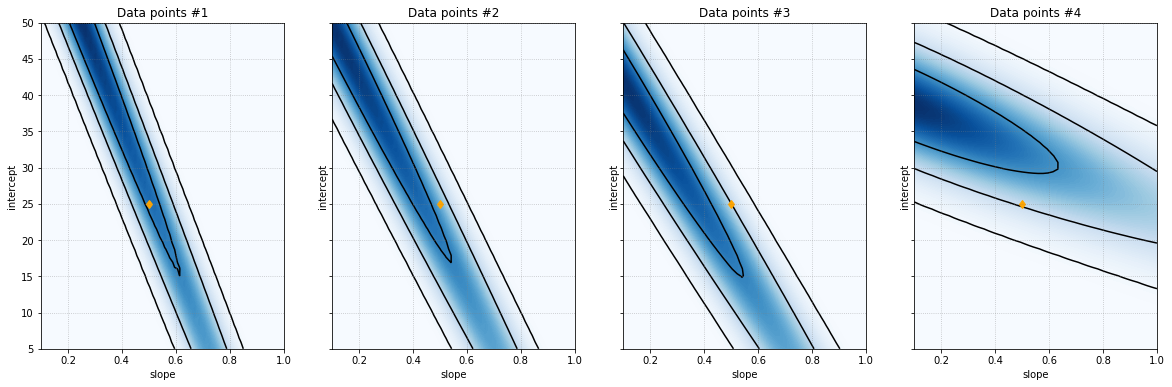

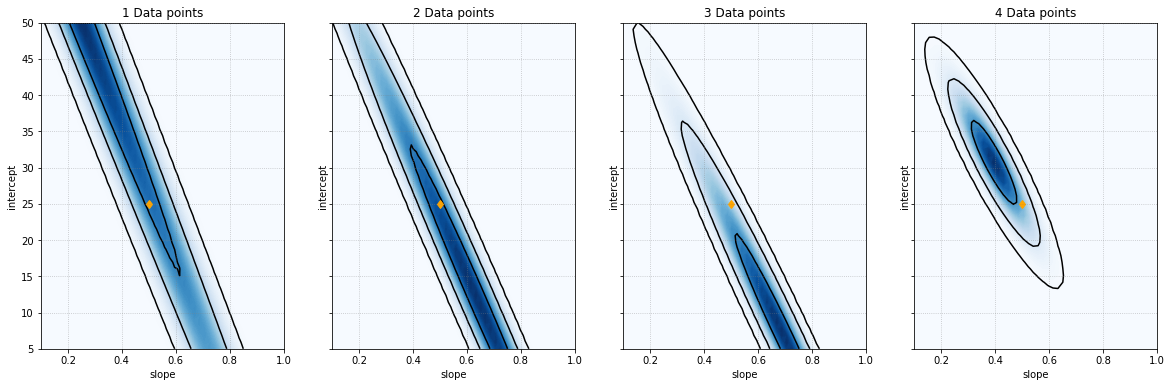

In [13]:
# let's first see the posterior associated to each data point (let's take the points 1, 2, 3, 4)
f, ax = plt.subplots(1, ncols=4, figsize=(20, 6), sharex=True, sharey=True)

for i in range(1, 5):
    axx = plot_results(x[i:i+1], y[i:i+1], sigy[i:i+1], ax=ax[i-1])
    axx.set_title('Data points #%i' %i)

f, ax = plt.subplots(1, ncols=4, figsize=(20, 6), sharex=True, sharey=True)

# Now, Let's see the posterior evolves when adding points one after the other
for i in range(1, 5):
    axx = plot_results(x[1:i+1], y[1:i+1], sigy[1:i+1], ax=ax[i-1])
    axx.set_title('%i Data points' %i)

Note that the baysian framework shows us that there is effectively information on the model parameters even when we have less data points than degrees of freedom! This makes sense as this data points limits the infinite number of solutions (i.e. the range of solution we would encode as a prior) one would would have without any data point. 

In the frequentist framework, with one data point, we would have a $\chi^2 = 0$ and no possibility to calculate a covariance matrix and say anything about the parameters in a formalised way. The Bayesian framework naturally alleviates this limitation, but beware that the information we have with 1 data point can yet depend substantially on the prior. 

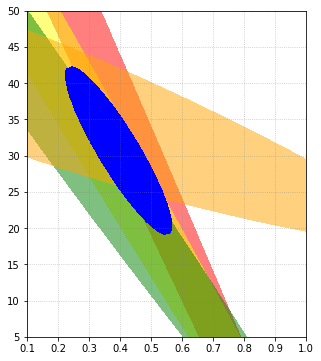

In [14]:
# We can also visualise the 2 sigma contours associated to the 4 points and the joint 2 sigma contours 
# 
f, ax = plt.subplots(1, ncols=1, figsize=(5, 6))

axx.set_title('%i Data points' %i)
color_list = ['red', 'yellow', 'green', 'orange']
for i in range(1, 5):
    slope_range, intercept_range, P2, c_levels = plot_results(x[i:i+1], y[i:i+1], sigy[i:i+1], 
                                                              ax=ax, outcontour=True)
    ax.contourf(slope_range, intercept_range, P2, [c_levels[1], 1], colors=color_list[i-1], alpha=0.5)

i = 4
slope_range, intercept_range, P2, c_levels = plot_results(x[1:i+1], y[1:i+1], sigy[1:i+1], 
                                                              ax=ax, outcontour=True)
#axx = plot_results(x[1:i+1], y[1:i+1], sigy[1:i+1], ax=ax)
ax.contourf(slope_range, intercept_range, P2, [c_levels[1], 1], colors='blue', alpha=1)
    
ax.grid('on', linestyle=':', color='gray', alpha=0.5)

We see that that blue contour (associated to 4 points) is at the "intersection" of the contours of the individual data points. 

Text(0.5, 1.0, '20 Data points')

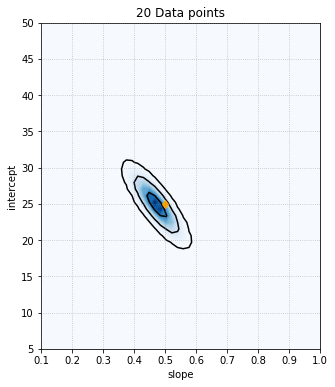

In [15]:
f, ax = plt.subplots(1, ncols=1, figsize=(5, 6))
ax = plot_results(x[0::], y[0::], sigy[0::], ax=ax)
ax.set_title('%i Data points' %20)

### Reference 

- The example shown in [Another-view-on-regression](#Another-view-on-regression) is a free adaptation of the example provided in Fig. 8.1 of our reference book <a class="anchor" id="book"></a> *Statistics, data mining and Machine learning in astronomy* by Z. Ivezic et al. in Princeton Series in Modern Astronomy. 
- More discussions (and debates) about the difference between confidence and credible intervals can be found in this [stackechange thread](https://stats.stackexchange.com/questions/2272/whats-the-difference-between-a-confidence-interval-and-a-credible-interval)  